# 最終課題：実践的なデータ解析


## 目的
アイオワ州の住宅価格データを使い、住宅価格に影響を与える要因を分析する。


## 仮説
- 居住面積（area）が大きいほど住宅価格は高くなる。
- 新しい住宅（YearBuiltが大きい）ほど住宅価格は高くなる。


                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     1695.
Date:                Tue, 23 Sep 2025   Prob (F-statistic):               0.00
Time:                        09:28:03   Log-Likelihood:                 146.14
No. Observations:                1460   AIC:                            -286.3
Df Residuals:                    1457   BIC:                            -270.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8132      0.379     -2.145      0.0

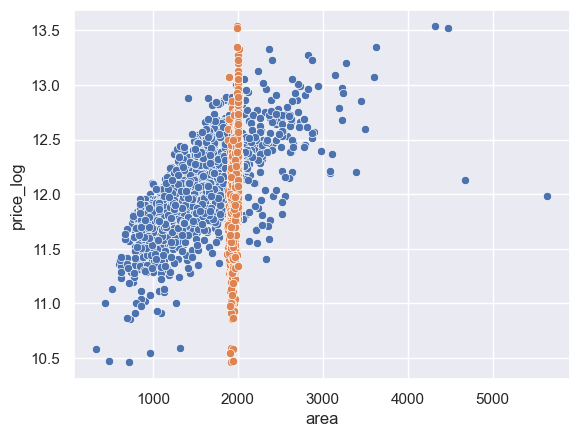

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# データ読み込み
data = pd.read_csv("iowa_ames_housing_price.csv")

# 列名をリネーム（GrLivArea → area）
data = data.rename(columns={"GrLivArea": "area"})

# priceを対数変換
data["price_log"] = np.log1p(data["price"])

# 欠損値処理
data = data.dropna(subset=["price_log", "area", "YearBuilt"])

# 散布図で確認
sns.scatterplot(x="area", y="price_log", data=data)
sns.scatterplot(x="YearBuilt", y="price_log", data=data)

# 線形回帰モデル（面積と築年数で説明）
model = ols("price_log ~ area + YearBuilt", data=data).fit()

# 結果表示
print(model.summary())


## 結果の考察
回帰分析の結果、居住面積と築年数はいずれも価格に有意に影響していた。  
決定係数は約0.70であり、モデルとしても十分な説明力がある。  
したがって、仮説は支持されたと考えられる。
